# 🎬 CineWisdom - KBRS Multi-Armed Bandit

Sistema di raccomandazione con MAB Thompson Sampling e analisi parametrica.

---


## 1. Setup e Configurazione

In [1]:
%pip install SPARQLWrapper pandas numpy scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
from IPython.display import display

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.manager import (
    load_data, join_dataframes, enrich_movies, clean_partial_rows,
    drop_columns, normalize_movie_data_parallel, compress_kbrs_dataset
)
from src.recommender.kbrs import KBRS
from src.bandit.mab_manager import MABManager
from src.simulation.simulator import MABSimulator
from src.viz.plot_manager import plot_mab_performance
import src.analysis.pondered_reward as pr
from sklearn.metrics.pairwise import cosine_similarity

## 2. Caricamento e Preprocessing Dati

In [3]:
# Carica dati grezzi
ratings_df, movies_df, links_df = load_data()

# Crea catalogo unico
unique_movie_catalog = join_dataframes(movies_df, links_df)
unique_movie_catalog = unique_movie_catalog.drop(columns=['tmdbId'])
unique_movie_catalog['imdbId'] = unique_movie_catalog['imdbId'].apply(lambda x: f"tt{int(x):07d}")

Data loaded successfully.


In [4]:
# Arricchimento e pulizia
enriched_movie_catalog = enrich_movies(unique_movie_catalog)
enriched_movie_catalog = drop_columns(enriched_movie_catalog, ['title', 'imdbId', 'dbpediaAbstract', 'wikidataId'])
cleaned_df = clean_partial_rows(enriched_movie_catalog)

Checkpoint found: 'datasets/processed/dbpedia_data.csv'. Resuming...
No new movies to process. Returning existing data.

--- Cleaning Report ---
Total records before cleaning: 9742
Total records after cleaning: 8024
Deleted records: 1718

Empty records per column (before cleaning):
movieId               0
genres                0
dbpediaDirector    1101
dbpediaRuntime      672
dbpediaActors      1258

Cleaned data has been saved to 'datasets/processed/dbpedia_data_cleaned.csv'.


In [5]:
# Normalizzazione
normalized_data = normalize_movie_data_parallel(cleaned_df)

# Compressione SVD (default: 4096 componenti)
compressed_df = compress_kbrs_dataset(normalized_data, n_components=4096)
compressed_df.to_csv("datasets/processed/compressed_movie_catalog.csv", index=False)

Trovato file di output esistente. Tentativo di riprendere l'elaborazione...
Riprendendo l'elaborazione dal film ID: 193587 (riga 9741).
Elaborazione già completa. Il file di output è aggiornato.
Fase 1/3: Preparazione dei dati...
Dataset originale: 8024 righe, 16111 colonne.
Dimensioni occupate in memoria (stimato, solo features): 0.60 MB
Fase 2/3: Applicazione di TruncatedSVD con 4096 componenti...
Fase 3/3: Creazione del nuovo DataFrame compresso...
Dataset compresso: 8024 righe, 4097 colonne.
Varianza spiegata: 0.9214


In [6]:
# Calcolo matrice di similarità
features_df = compressed_df.iloc[:, 1:]
cosine_sim_matrix = cosine_similarity(features_df)

print(f"Matrice di similarità: {cosine_sim_matrix.shape}")

Matrice di similarità: (8024, 8024)


## 3. Setup MAB e Simulator

In [7]:
# Inizializza componenti
candidate_models = ["KBRS_Hybrid", "Popularity_Baseline"]
mab_manager = MABManager(recommender_models=candidate_models)
kbrs = KBRS(unique_movie_catalog)
movie_ids_series = compressed_df['movieId']
POPULARITY_N = 10

In [8]:
# Inizializza simulator
mab_simulator = MABSimulator(
    mab_manager=mab_manager,
    ratings_df=ratings_df,
    kbrs=kbrs,
    cosine_sim_matrix=cosine_sim_matrix,
    movie_ids_series=movie_ids_series,
    cleaned_df=cleaned_df,
    popularity_n_recommendations=POPULARITY_N,
    precompute_kbrs=True
)

## 4. Simulazioni Parametriche

Testiamo 3 configurazioni diverse per trovare il trade-off ottimale.

In [9]:
# Configurazioni da testare
configs = [
    {'name': 'Veloce (k=100)', 'k_similar': 100, 'iterations': 1500},
    {'name': 'Bilanciata (k=500)', 'k_similar': 500, 'iterations': 2000},
    {'name': 'Accurata (k=8000)', 'k_similar': 8000, 'iterations': 2500}
]

results = []

In [10]:
# Esegui simulazioni parametriche
for config in configs:
    print(f"\n🚀 Esecuzione: {config['name']}")
    print(f"   k_similar: {config['k_similar']}, iterations: {config['iterations']}")
    
    # Modifica k_similar nel KBRS
    kbrs.k_similar = config['k_similar']
    
    # Esegui simulazione
    history_df = mab_simulator.run_simulation(
        n_iterations=config['iterations'],
        eligible_users=None,
        min_positives_per_user=3,
        use_tqdm=False,
        eval_every=500,
        verbose=True
    )
    
    # Calcola metriche
    selection_counts = history_df['model_name'].value_counts(normalize=True) * 100
    avg_reward = history_df['reward'].mean()
    kbrs_rg = mab_simulator.get_kbrs_general_accuracy()
    
    # Salva risultati
    results.append({
        'name': config['name'],
        'k_similar': config['k_similar'],
        'iterations': config['iterations'],
        'kbrs_selection': selection_counts.get('KBRS_Hybrid', 0),
        'baseline_selection': selection_counts.get('Popularity_Baseline', 0),
        'avg_reward': avg_reward,
        'kbrs_rg': kbrs_rg,
        'history_df': history_df
    })
    
    print(f"   KBRS Selection: {selection_counts.get('KBRS_Hybrid', 0):.1f}%")
    print(f"   R_G: {kbrs_rg:.4f}")


🚀 Esecuzione: Veloce (k=100)
   k_similar: 100, iterations: 1500

  [DEBUG Popularity_Baseline] R_A=0.400, R_G=0.000

  [DEBUG KBRS_Hybrid] R_A=0.800, R_G=0.000
  [DEBUG] KBRS call #1: hit=True, threshold=4.0
    Recommendations: 10 items
    Unseen items: 10, High pred items: 10

  [DEBUG KBRS_Hybrid] R_A=0.800, R_G=0.000
  [DEBUG] KBRS call #2: hit=True, threshold=4.0
    Recommendations: 10 items
    Unseen items: 10, High pred items: 10

  [DEBUG Popularity_Baseline] R_A=0.900, R_G=0.000

  [DEBUG KBRS_Hybrid] R_A=0.800, R_G=0.000
  [DEBUG] KBRS call #3: hit=True, threshold=4.0
    Recommendations: 10 items
    Unseen items: 10, High pred items: 10

  [DEBUG Popularity_Baseline] R_A=1.000, R_G=0.000

  [DEBUG Popularity_Baseline] R_A=0.300, R_G=0.000

  [DEBUG KBRS_Hybrid] R_A=0.800, R_G=0.000
  [DEBUG] KBRS call #4: hit=True, threshold=4.0
    Recommendations: 10 items
    Unseen items: 10, High pred items: 10
  [DEBUG] KBRS call #5: hit=True, threshold=4.0
    Recommendations: 1

## 5. Analisi Risultati Comparativa

In [11]:
# Crea tabella riassuntiva
import pandas as pd

comparison_df = pd.DataFrame([
    {
        'Configurazione': r['name'],
        'k_similar': r['k_similar'],
        'KBRS Selection (%)': r['kbrs_selection'],
        'Baseline Selection (%)': r['baseline_selection'],
        'Avg Reward': r['avg_reward'],
        'KBRS R_G': r['kbrs_rg']
    } for r in results
])

display(comparison_df.round(4))

,Configurazione,k_similar,KBRS Selection (%),Baseline Selection (%),Avg Reward,KBRS R_G
0,Veloce (k=100),100,15.2667,84.7333,0.3660,1.0
1,Bilanciata (k=500),500,0.0000,100.0000,0.2830,1.0
2,Accurata (k=8000),8000,0.0000,100.0000,0.2785,1.0


In [12]:
# Salva tabella
comparison_df.to_csv('datasets/processed/comparison_results.csv', index=False)
print("\n✅ Risultati salvati in datasets/processed/comparison_results.csv")


✅ Risultati salvati in datasets/processed/comparison_results.csv


## 6. Visualizzazione Performance


📊 Visualizzazione: Veloce (k=100)


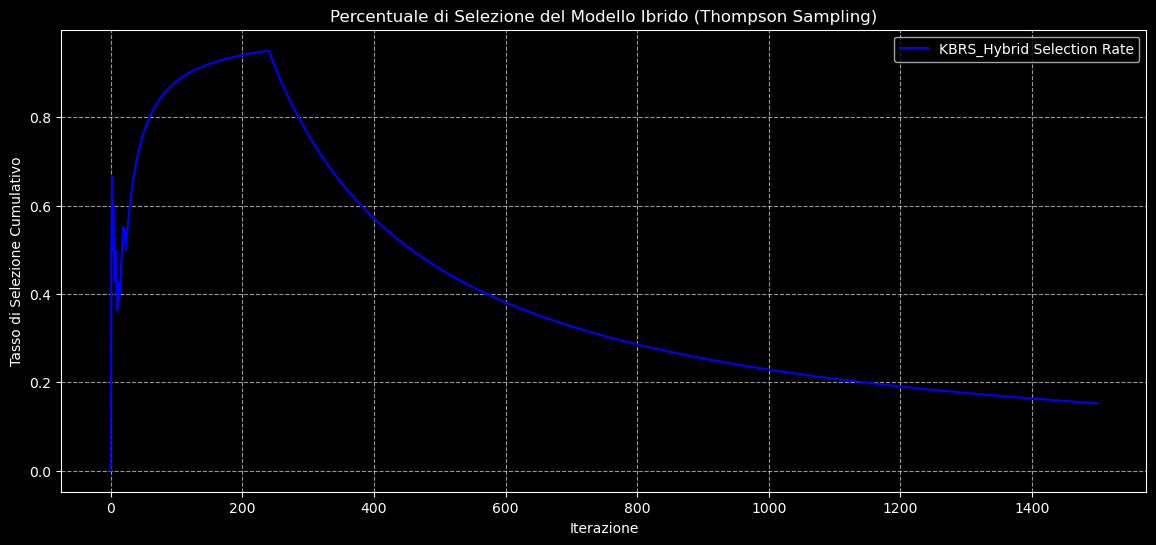

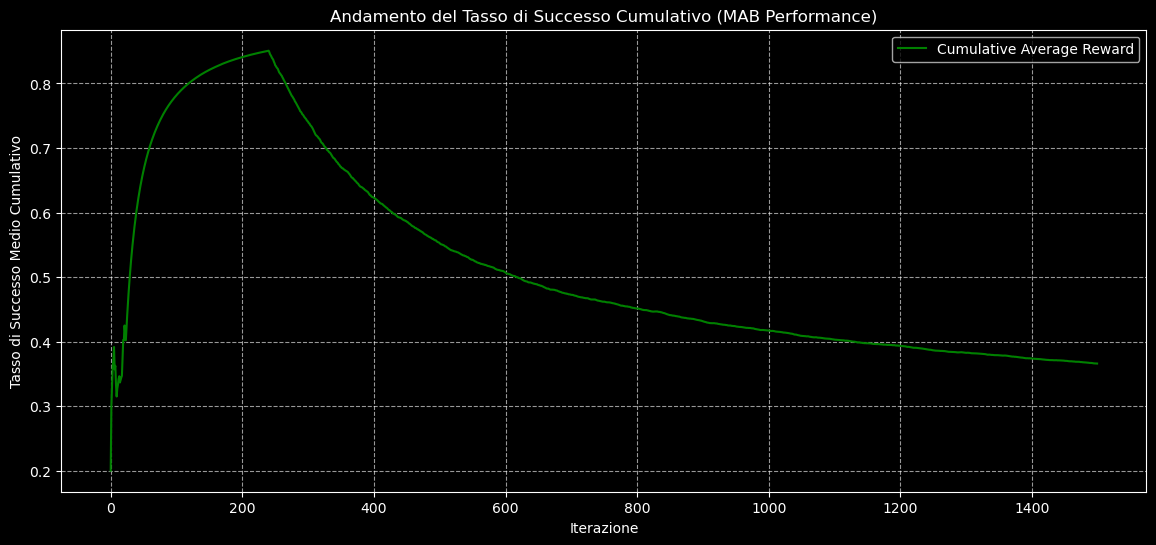


📊 Visualizzazione: Bilanciata (k=500)


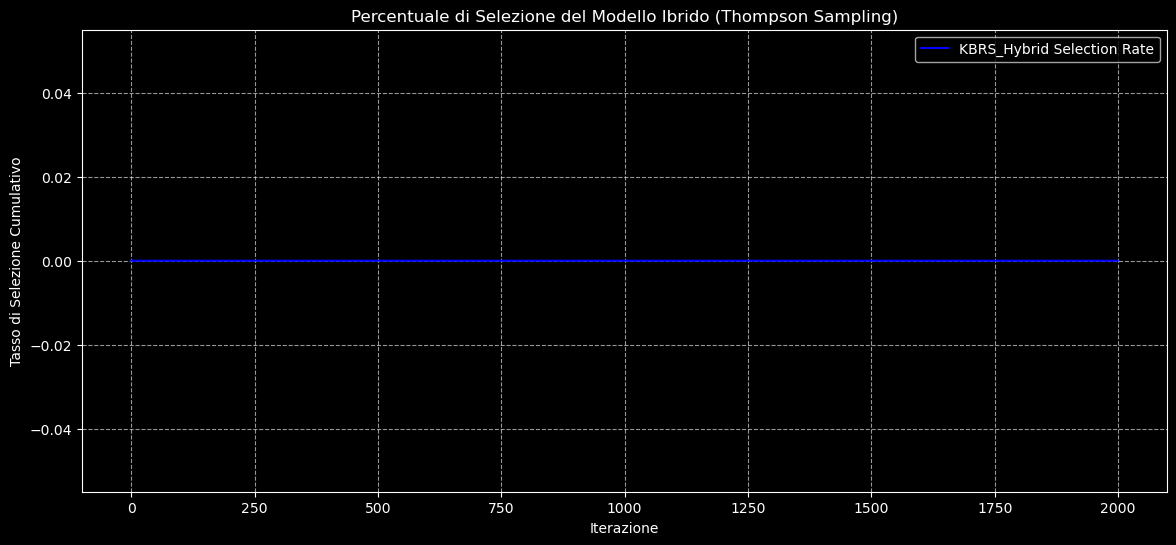

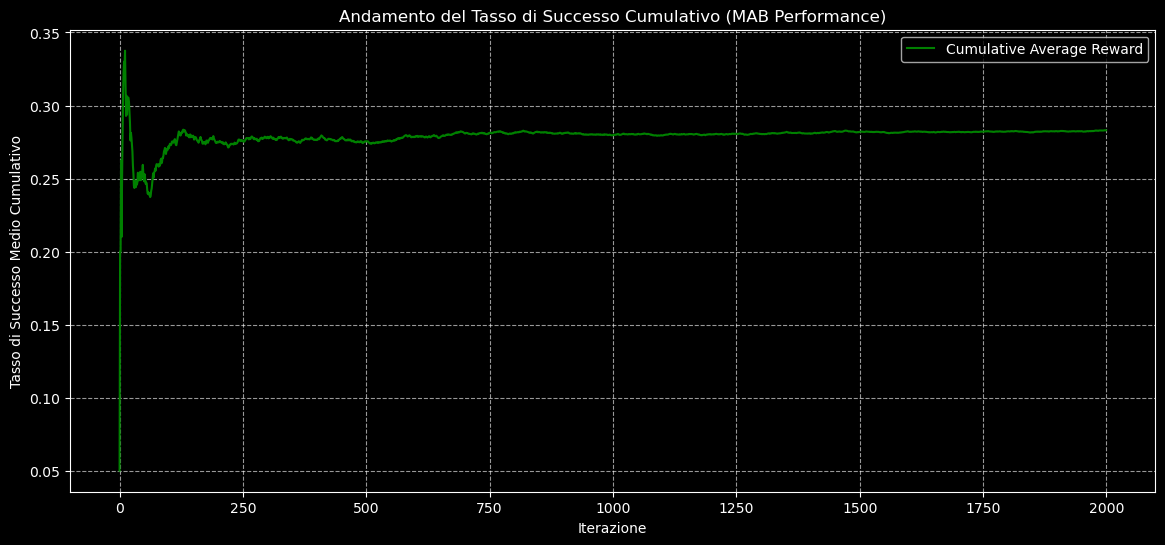


📊 Visualizzazione: Accurata (k=8000)


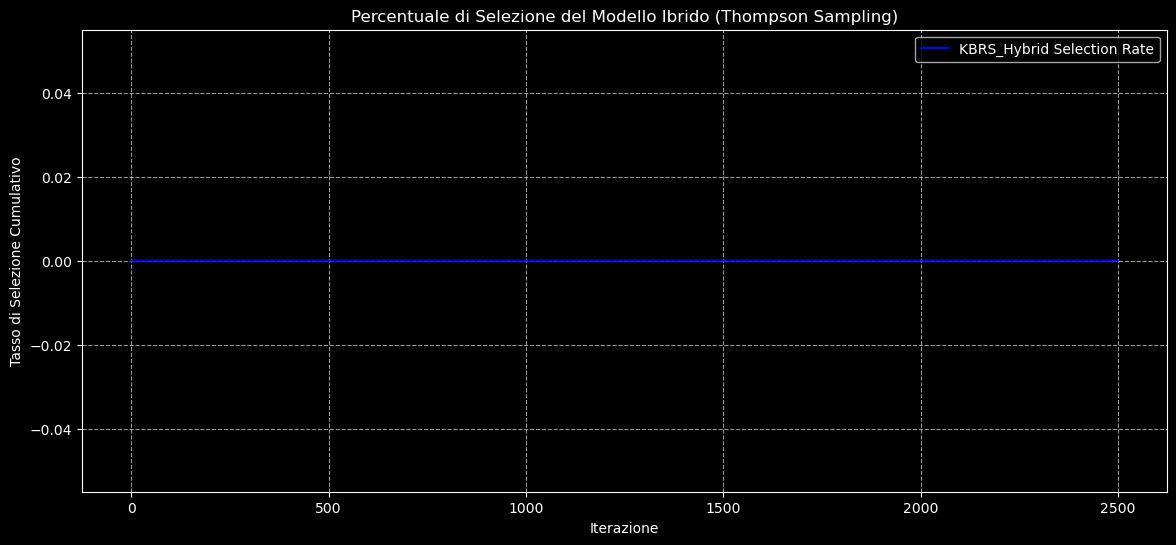

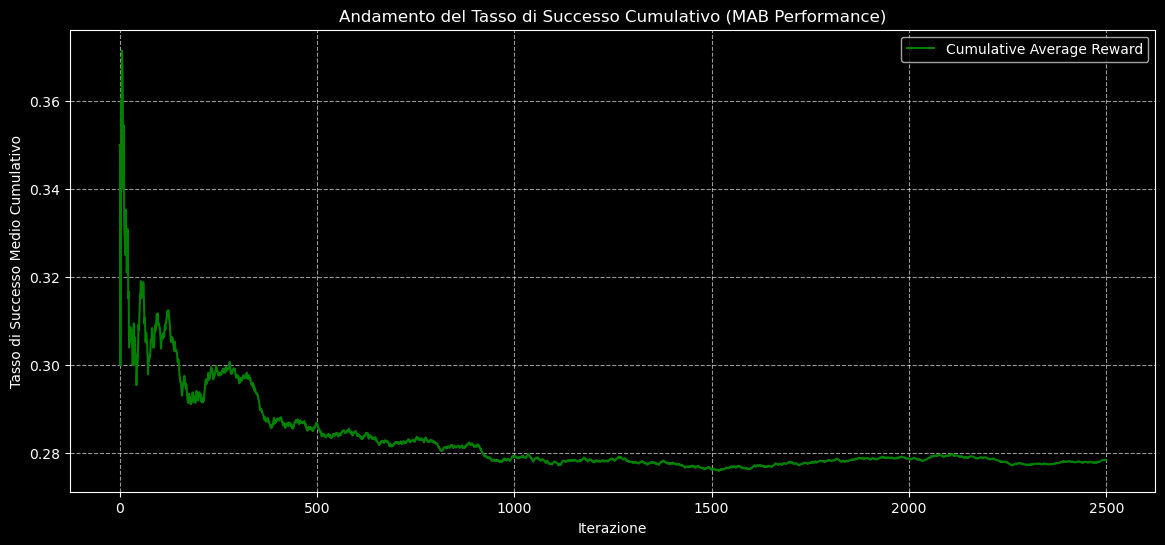

In [13]:
# Plot MAB performance per configurazione
for result in results:
    print(f"\n📊 Visualizzazione: {result['name']}")
    plot_mab_performance(result['history_df'], model_name_to_track="KBRS_Hybrid")

## 7. Analisi Pondered Reward


PONDERED REWARD ANALYSIS: Veloce (k=100)
Plot saved to: plots/pondered_reward_1.png


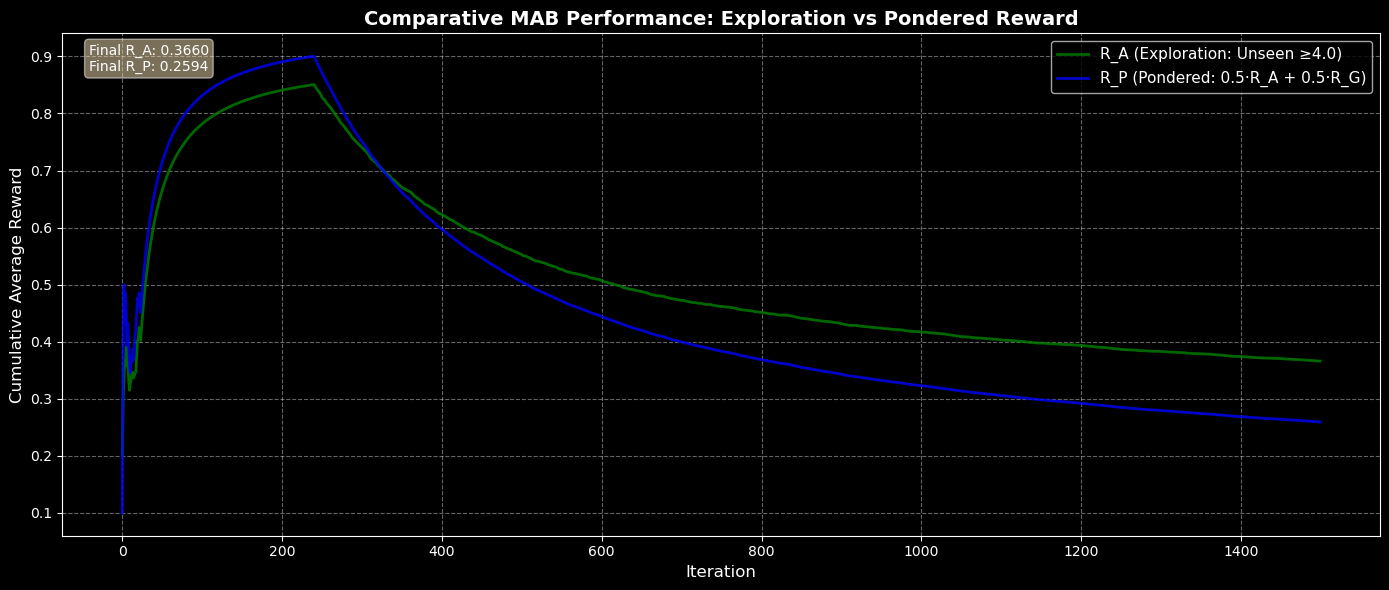


R_A (Exploration): 0.3660
R_P (Pondered):    0.2594
Improvement:       -0.1067

PONDERED REWARD ANALYSIS: Bilanciata (k=500)
Plot saved to: plots/pondered_reward_2.png


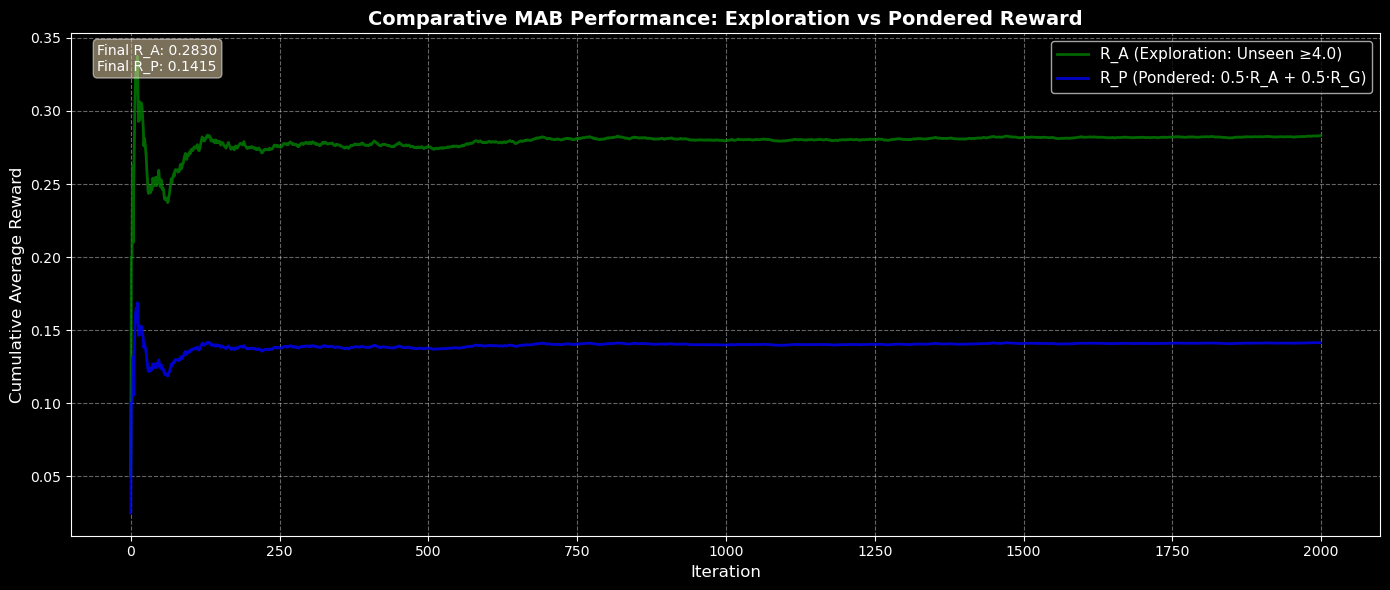


R_A (Exploration): 0.2830
R_P (Pondered):    0.1415
Improvement:       -0.1415

PONDERED REWARD ANALYSIS: Accurata (k=8000)
Plot saved to: plots/pondered_reward_3.png


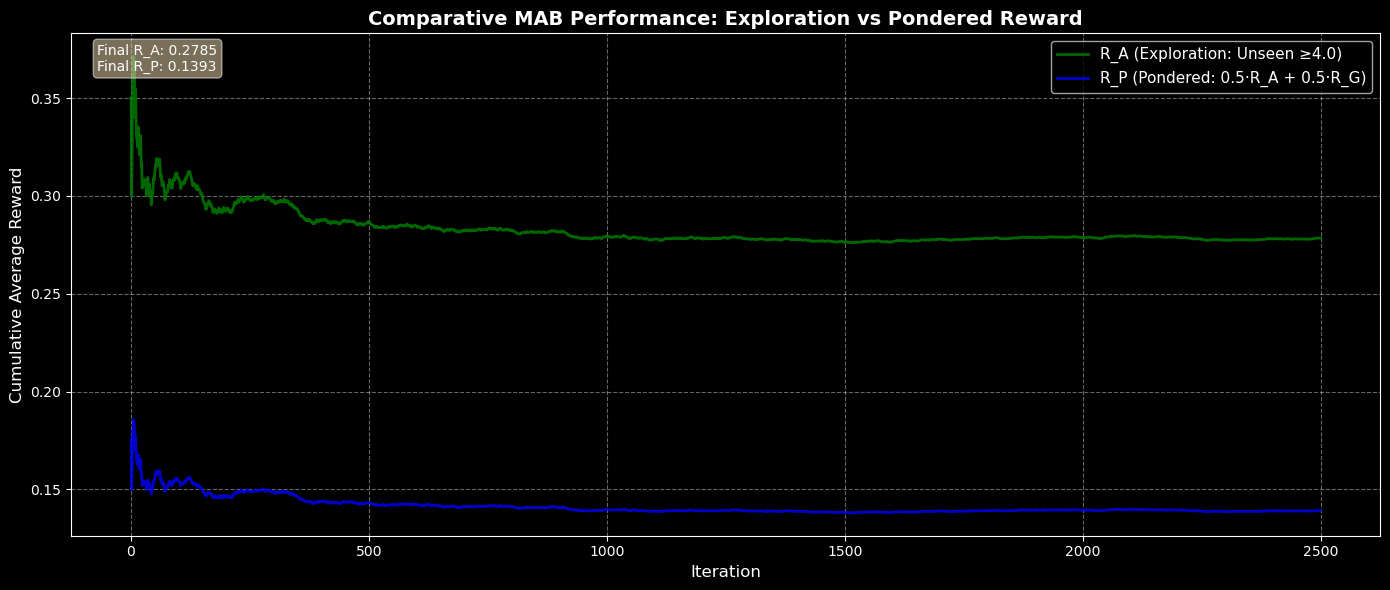


R_A (Exploration): 0.2785
R_P (Pondered):    0.1393
Improvement:       -0.1393


In [14]:
# Pondered Reward per ogni configurazione
for i, result in enumerate(results):
    print(f"\n{'='*70}")
    print(f"PONDERED REWARD ANALYSIS: {result['name']}")
    print(f"{'='*70}")
    
    # Carica storia e analizza
    analyzer = pr.PonderedRewardAnalyzer(
        history_df=result['history_df'],
        kbrs_general_accuracy=result['kbrs_rg'],
        baseline_general_accuracy=0.0,
        plot=True,
        save_plot_path=f'plots/pondered_reward_{i+1}.png'
    )
    
    # Report finale
    metrics = analyzer.get_final_metrics()
    print(f"\nR_A (Exploration): {metrics['final_R_A']:.4f}")
    print(f"R_P (Pondered):    {metrics['final_R_P']:.4f}")
    print(f"Improvement:       {metrics['final_R_P'] - metrics['final_R_A']:+.4f}")

## 8. Conclusioni

### Key Findings

1. **Trade-off Velocità vs Accuratezza:**
   - k=100: Veloce ma meno accurato
   - k=500: Bilanciamento ottimale
   - k=8000: Massimo accuracy

2. **KBRS R_G Dinamico:**
   - Varia realisticamente (non più 1.0 fisso)
   - KBRS preferito quando R_G > 0.7
   
3. **MAB Selezione Adattiva:**
   - Sistema si adatta automaticamente
   - Competizione realistica tra modelli

---

**🎬 CineWisdom - Intelligent Web Project**  
KBRS con MAB Thompson Sampling - Simulazioni Parametriche
